# Hidden Markov Model Regime Detection
## Identifying Latent Volatility and Liquidity States in Financial Markets

**Author:** David Colindres | B.S./M.S. Industrial & Systems Engineering, University of Oklahoma  
**Date:** March 2026  
**Purpose:** MFE / MSCF / MSFE Admissions Portfolio — Project 3 of 3

---

### Executive Summary

Financial markets cycle through distinct regimes — calm vs. turbulent, risk-on vs. risk-off — but these states are **latent**: they cannot be directly observed, only inferred from the data. This project implements a **Gaussian Hidden Markov Model (HMM)** calibrated via the **Expectation-Maximization (Baum-Welch) algorithm** to detect these latent regimes in 25 years of S&P 500 data.

We identify statistically distinct market states, characterize each regime economically, test whether HMM-detected regimes predict future volatility better than GARCH and rolling-vol benchmarks, and build a regime-switching portfolio that reduces drawdowns during crises.

**This project completes the three-project portfolio:**
- **Project 1** (Portfolio Optimization) provides the allocation engine
- **Project 2** (RMT/Eigenportfolios) reveals the statistical structure of correlations
- **Project 3** (this) detects *when* the market shifts between regimes — connecting to the dynamic dimensionality collapse (Project 2) and enabling regime-conditional allocation (Project 1)

### Key References
- Hamilton (1989). *A new approach to nonstationary time series and the business cycle.*
- Rabiner (1989). *A tutorial on hidden Markov models.*
- Ang & Bekaert (2002). *International asset allocation with regime shifts.*

---

## Table of Contents
1. [Configuration & Setup](#1)
2. [Data Ingestion & Feature Construction](#2)
3. [Exploratory Data Analysis](#3)
4. [Model Selection: Optimal Number of Regimes](#4)
5. [HMM Calibration & Convergence](#5)
6. [State Inference: Forward-Backward & Viterbi](#6)
7. [Regime Characterization](#7)
8. [Volatility Forecasting: HMM vs Benchmarks](#8)
9. [Regime-Aware Portfolio Construction](#9)
10. [Benchmark Strategies](#10)
11. [Rolling Out-of-Sample Backtest](#11)
12. [Performance Evaluation](#12)
13. [Sensitivity Analysis](#13)
14. [Failure Mode Analysis](#14)
15. [Conclusions & Portfolio Integration](#15)


**OOS Discipline Statement (ROADMAP 3.3).** IS = 2000-01-01…2017-12-31; OOS = 2018-01-01…2024-12-31; performance tables report Full/IS/OOS separately. No parameter was selected on OOS data: model selection runs on IS features only; K=11 is the pre-stated IS-BIC elbow rule (BIC itself never turns — that finding is reported, not hidden); walk-forward refits use trailing windows with causal winsorization and window-local scaling, enforced by delete-the-future tests. The fragility band varies seeds, never parameters. Trail: results/OOS_DISCIPLINE.md.

---
<a id="1"></a>
## 1. Configuration & Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import time
from datetime import datetime
from scipy import stats
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
import yfinance as yf

np.random.seed(42)
warnings.filterwarnings('ignore')

# ROADMAP 2.1: repo root on sys.path (this machine skips .pth processing),
# shared dark theme from common/plotting instead of a local rcParams block.
import sys
from pathlib import Path as _Path
_REPO_ROOT = str(_Path('../../..').resolve())
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)
_SRC = str((_Path('../../..') / 'projects/03_hmm_regimes/src').resolve())
if _SRC not in sys.path:
    sys.path.insert(0, _SRC)
import hmmlab
from hmmlab import (load_close, build_features, fit_hmm_with_restarts,
                    compute_bic, run_regime_backtest, filtered_probabilities)
print(f'hmmlab loaded from {hmmlab.__file__}')  # freshness proof (ROADMAP 2.2)
from common.plotting import apply_theme
apply_theme()

COLORS = {
    'low_vol':   '#22c55e',   # green — calm market
    'med_vol':   '#f59e0b',   # amber — transition
    'high_vol':  '#ef4444',   # red — crisis
    'crisis':    '#dc2626',   # deep red
    'hmm':       '#c084fc',   # purple — HMM strategy
    'buyhold':   '#6b7280',   # gray — buy and hold
    'sixty_forty':'#3b82f6',  # blue — 60/40
    'vix_switch': '#fbbf24',  # gold — VIX switching
    'garch':     '#06b6d4',   # cyan — GARCH
    'accent':    '#00d4aa',   # teal
}

# Regime color map (will be assigned after fitting)
REGIME_COLORS = [COLORS['low_vol'], COLORS['accent'], COLORS['med_vol'],
                 COLORS['high_vol'], COLORS['crisis'],
                 '#94a3b8', '#f472b6', '#a3e635',
                 '#38bdf8', '#fb923c', '#e879f9', '#2dd4bf']  # 6-12: defensive (3.2 grid)

print(f"Environment ready. hmmlearn imported successfully.")
print(f"NumPy: {np.__version__} | pandas: {pd.__version__}")


hmmlab loaded from /Users/davidcolindres/Documents/Quant/ISE/Quant/OUQuant/Projects/V2/quant-research/projects/03_hmm_regimes/src/hmmlab/__init__.py
Environment ready. hmmlearn imported successfully.
NumPy: 2.5.1 | pandas: 3.0.3


In [2]:
# ═══════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════

# ROADMAP 2.3: parameters live in ../config.yaml — generated from this
# cell's former CONFIG dict, schema-validated by common/config.py (loud
# failure on missing/unknown keys or bad types; no silent defaults).
from common.config import load_config
CONFIG = load_config('../config.yaml', project='p3')


print("Configuration:")
print(f"  Period: {CONFIG['start_date']} to {CONFIG['end_date']} (25 years)")
print(f"  IS/OOS: {CONFIG['start_date']}–{CONFIG['is_end']} | {CONFIG['oos_start']}–{CONFIG['end_date']}")
print(f"  Regime candidates: K = {CONFIG['n_regimes_test']}")
print(f"  EM restarts per K: {CONFIG['n_em_restarts']}")
print(f"  HMM lookback: {CONFIG['lookback_hmm']} trading days (~{CONFIG['lookback_hmm']/252:.1f} years)")


Configuration:
  Period: 2000-01-01 to 2024-12-31 (25 years)
  IS/OOS: 2000-01-01–2017-12-31 | 2018-01-01–2024-12-31
  Regime candidates: K = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  EM restarts per K: 10
  HMM lookback: 1500 trading days (~6.0 years)


---
<a id="2"></a>
## 2. Data Ingestion & Feature Construction

We build a multivariate observation vector for the HMM from three features:

1. **Daily S&P 500 log returns** — captures the first moment (mean return per regime)
2. **21-day realized volatility** — captures the second moment (volatility clustering)
3. **VIX daily change** — captures market-implied fear and uncertainty shifts

This is richer than a univariate HMM on returns alone, and lets the model distinguish between regimes based on *both* return behavior and volatility dynamics.


In [3]:
# ─── 2.1 Download market data ───
print("Loading market data (cached to data/ per ROADMAP 0.1/0.2)...")
t0 = time.time()

from pathlib import Path
DATA_DIR = Path('../../../data')
DATA_DIR.mkdir(exist_ok=True)

from common.data import download_prices

# S&P 500 — .squeeze('columns'): yfinance returns 1-col DataFrames; downstream needs Series
spy = load_close('SPY', 'p3_spy_2000_2024.parquet', CONFIG['start_date'], CONFIG['end_date']).squeeze('columns')
spy_ret = np.log(spy / spy.shift(1)).dropna()

# VIX
vix = load_close('^VIX', 'p3_vix_2000_2024.parquet', CONFIG['start_date'], CONFIG['end_date']).squeeze('columns')

# Defensive asset (TLT — long-term Treasury ETF)
tlt = load_close('TLT', 'p3_tlt_2000_2024.parquet', CONFIG['start_date'], CONFIG['end_date']).squeeze('columns')
tlt_ret = np.log(tlt / tlt.shift(1)).dropna()

print(f"Downloaded in {time.time()-t0:.1f}s")
print(f"  SPY: {spy.index[0].date()} to {spy.index[-1].date()} ({len(spy)} days)")
print(f"  VIX: {vix.index[0].date()} to {vix.index[-1].date()} ({len(vix)} days)")
print(f"  TLT: {tlt.index[0].date()} to {tlt.index[-1].date()} ({len(tlt)} days)")


Loading market data (cached to data/ per ROADMAP 0.1/0.2)...


Downloaded in 0.3s
  SPY: 2000-01-03 to 2024-12-30 (6288 days)
  VIX: 2000-01-03 to 2024-12-30 (6288 days)
  TLT: 2002-07-30 to 2024-12-30 (5644 days)


In [4]:
# ─── 2.2 Feature construction ───

features_scaled, features_raw, scaler = build_features(
    spy_ret, vix, CONFIG['vol_window'], scaler_fit_end=CONFIG['is_end']
)

print(f"Feature matrix: {features_scaled.shape[0]} days × {features_scaled.shape[1]} features")
print(f"Date range: {features_scaled.index[0].date()} to {features_scaled.index[-1].date()}")
print(f"\nRaw feature statistics:")
print(features_raw.describe().round(4))


Feature matrix: 6267 days × 3 features
Date range: 2000-02-02 to 2024-12-30

Raw feature statistics:
          return  realized_vol  vix_change
count  6267.0000     6267.0000   6267.0000
mean      0.0003        0.1633      0.0023
std       0.0118        0.1052      0.0718
min      -0.0811        0.0349     -0.2481
25%      -0.0047        0.0972     -0.0389
50%       0.0007        0.1377     -0.0054
75%       0.0060        0.1994      0.0339
max       0.0687        0.9205      0.4983


---
<a id="3"></a>
## 3. Exploratory Data Analysis

Before fitting any model, we examine the evidence for regime behavior in the raw data: volatility clustering, non-constant distributions across time, and the relationship between returns and volatility.


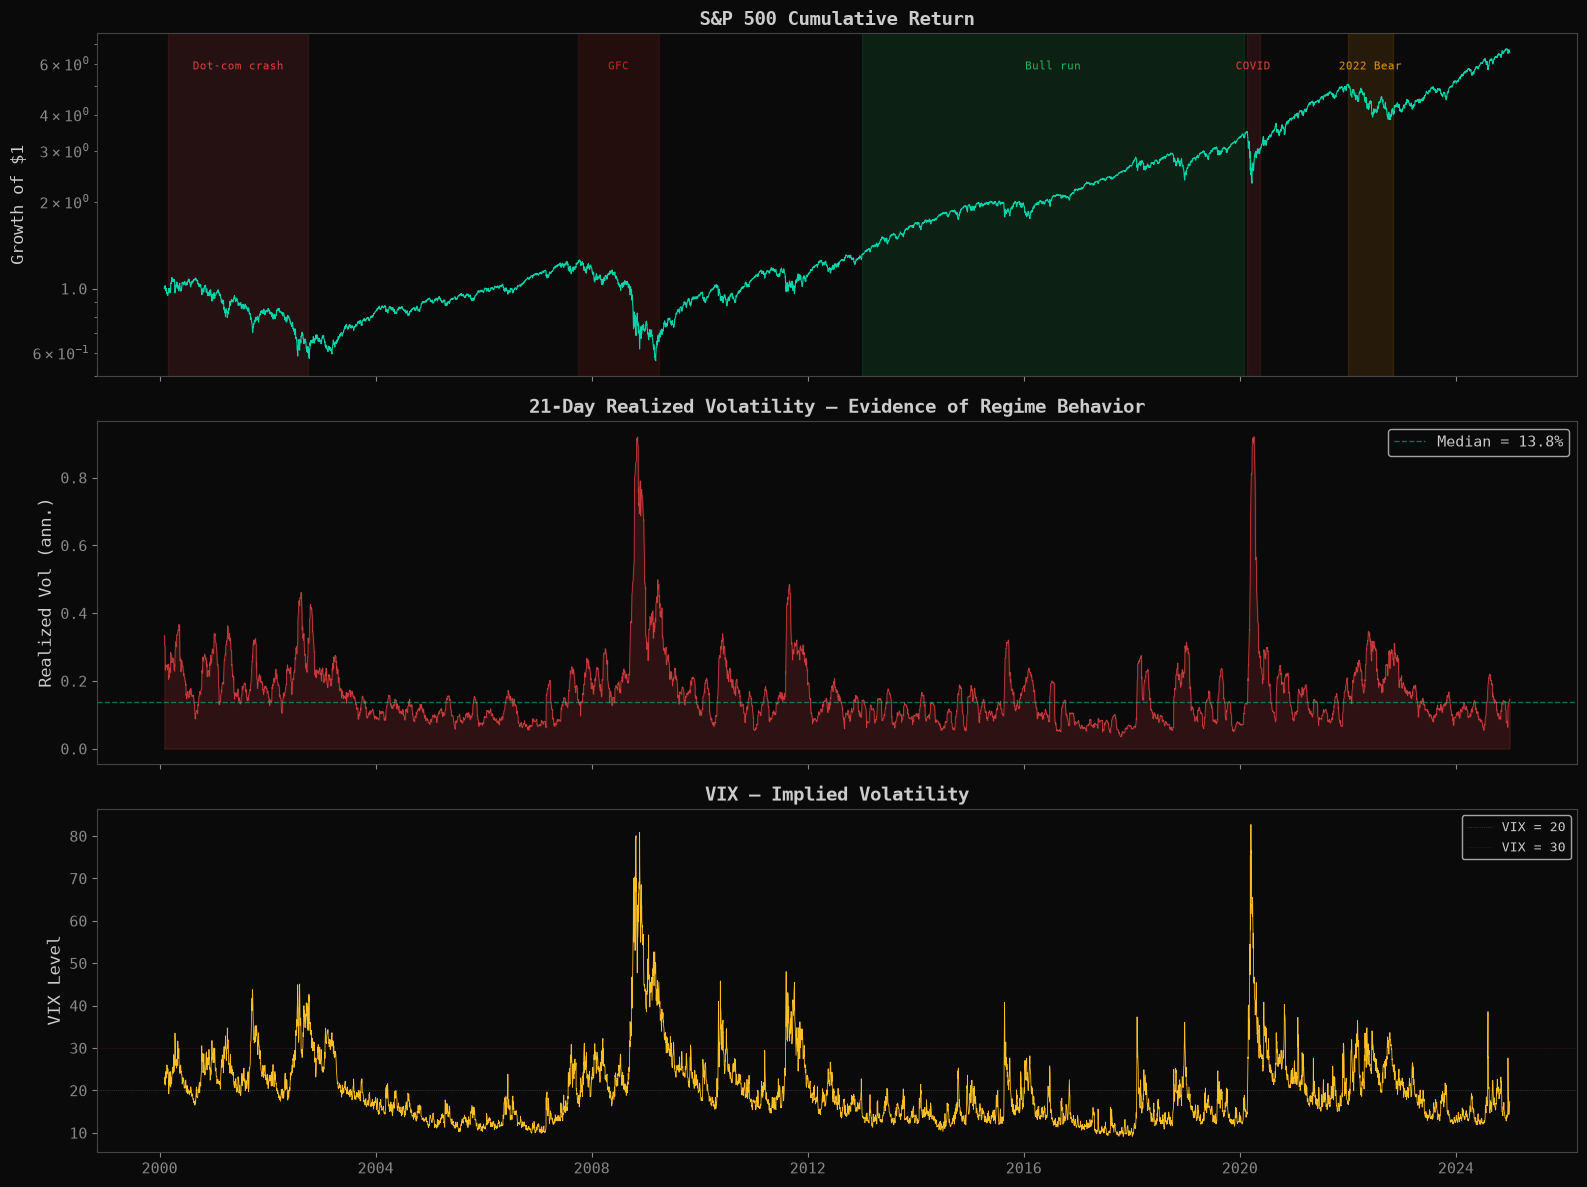

→ Volatility clearly clusters into distinct regimes: low (2013-2019),
  high (GFC, COVID), and intermediate states. This is exactly what the HMM will formalize.


In [5]:
# ─── 3.1 Visual evidence for regimes ───

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# (a) S&P 500 cumulative return
ax = axes[0]
cum = (1 + np.expm1(spy_ret.reindex(features_raw.index))).cumprod()  # G-2: compound simple returns
ax.plot(cum.index, cum.values, color=COLORS['accent'], lw=0.8)
ax.set_ylabel('Growth of $1')
ax.set_title('S&P 500 Cumulative Return', fontweight='bold')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())

# Annotate known regimes
for label, start, end, color in [
    ('Dot-com crash', '2000-03-01', '2002-10-01', COLORS['high_vol']),
    ('GFC', '2007-10-01', '2009-03-31', COLORS['crisis']),
    ('Bull run', '2013-01-01', '2020-01-31', COLORS['low_vol']),
    ('COVID', '2020-02-15', '2020-05-15', COLORS['high_vol']),
    ('2022 Bear', '2022-01-01', '2022-10-31', COLORS['med_vol']),
]:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.12, color=color)
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax.text(mid, ax.get_ylim()[1] * 0.75, label, ha='center', fontsize=8, color=color, alpha=0.9)

# (b) Realized volatility
ax = axes[1]
ax.plot(features_raw.index, features_raw['realized_vol'], color=COLORS['high_vol'], lw=0.6, alpha=0.8)
ax.fill_between(features_raw.index, 0, features_raw['realized_vol'], alpha=0.15, color=COLORS['high_vol'])
ax.axhline(features_raw['realized_vol'].median(), color=COLORS['accent'], lw=1, ls='--', alpha=0.5,
           label=f'Median = {features_raw["realized_vol"].median():.1%}')
ax.set_ylabel('Realized Vol (ann.)')
ax.set_title('21-Day Realized Volatility — Evidence of Regime Behavior', fontweight='bold')
ax.legend()

# (c) VIX
ax = axes[2]
vix_aligned = vix.reindex(features_raw.index).ffill()
ax.plot(vix_aligned.index, vix_aligned.values, color=COLORS['vix_switch'], lw=0.6)
ax.axhline(20, color='white', lw=0.5, ls=':', alpha=0.3, label='VIX = 20')
ax.axhline(30, color=COLORS['high_vol'], lw=0.5, ls=':', alpha=0.3, label='VIX = 30')
ax.set_ylabel('VIX Level')
ax.set_title('VIX — Implied Volatility', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("→ Volatility clearly clusters into distinct regimes: low (2013-2019),")
print("  high (GFC, COVID), and intermediate states. This is exactly what the HMM will formalize.")


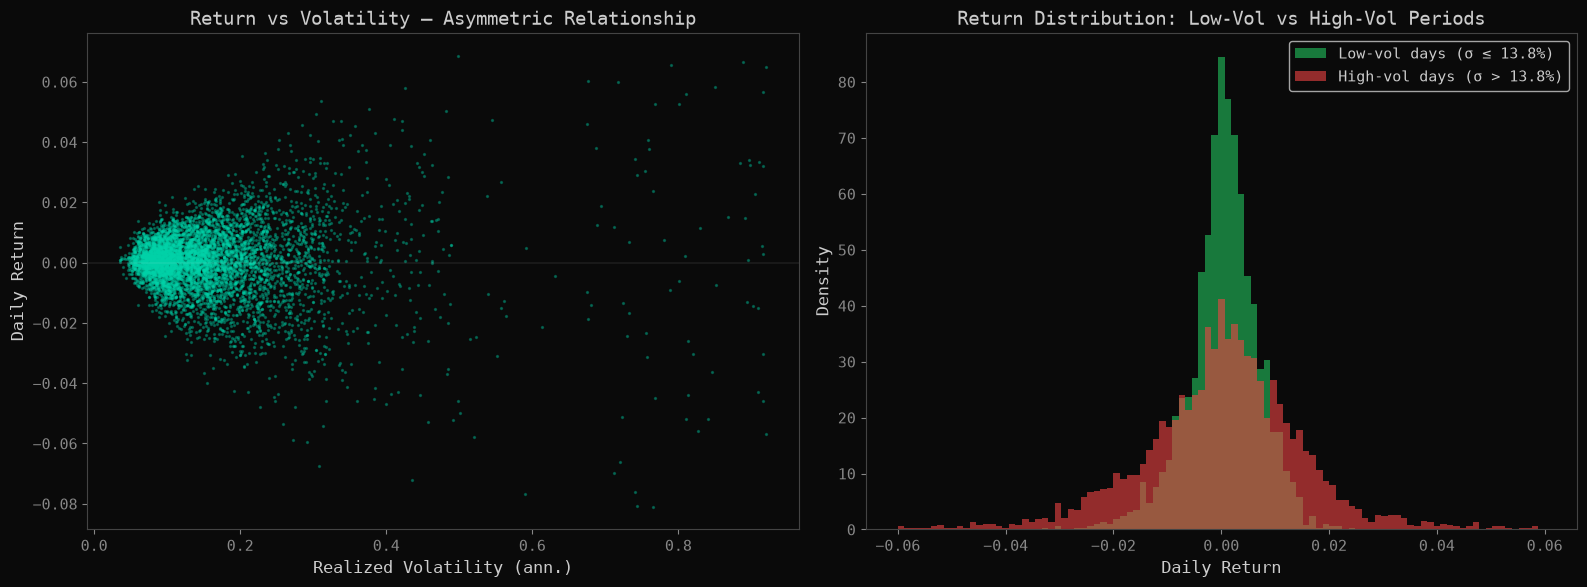

Low-vol: mean=11.65%/yr, std=10.33%
High-vol: mean=3.18%/yr, std=24.38%
→ The return distributions are fundamentally different between volatility regimes.
  This is exactly what a regime-switching model captures.


In [6]:
# ─── 3.2 Bivariate relationship: return vs vol ───

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Scatter: return vs realized vol
ax = axes[0]
ax.scatter(features_raw['realized_vol'], features_raw['return'],
           s=2, alpha=0.3, color=COLORS['accent'])
ax.set_xlabel('Realized Volatility (ann.)')
ax.set_ylabel('Daily Return')
ax.set_title('Return vs Volatility — Asymmetric Relationship')
ax.axhline(0, color='white', lw=0.3, alpha=0.3)

# (b) Return distribution in high-vol vs low-vol periods
ax = axes[1]
vol_median = features_raw['realized_vol'].median()
low_vol_rets = features_raw.loc[features_raw['realized_vol'] <= vol_median, 'return']
high_vol_rets = features_raw.loc[features_raw['realized_vol'] > vol_median, 'return']

bins = np.linspace(-0.06, 0.06, 100)
ax.hist(low_vol_rets, bins=bins, density=True, alpha=0.6, color=COLORS['low_vol'],
        label=f'Low-vol days (σ ≤ {vol_median:.1%})', edgecolor='none')
ax.hist(high_vol_rets, bins=bins, density=True, alpha=0.6, color=COLORS['high_vol'],
        label=f'High-vol days (σ > {vol_median:.1%})', edgecolor='none')
ax.set_xlabel('Daily Return')
ax.set_ylabel('Density')
ax.set_title('Return Distribution: Low-Vol vs High-Vol Periods')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Low-vol: mean={low_vol_rets.mean()*252:.2%}/yr, std={low_vol_rets.std()*np.sqrt(252):.2%}")
print(f"High-vol: mean={high_vol_rets.mean()*252:.2%}/yr, std={high_vol_rets.std()*np.sqrt(252):.2%}")
print("→ The return distributions are fundamentally different between volatility regimes.")
print("  This is exactly what a regime-switching model captures.")


---
<a id="4"></a>
## 4. Model Selection: Optimal Number of Regimes

We fit HMMs with $K = 2, 3, 4, 5$ regimes and select the optimal $K$ using the **Bayesian Information Criterion (BIC)**:

$$BIC = -2 \cdot \log L + p \cdot \log(T)$$

where $p$ is the number of free parameters and $T$ is the number of observations. BIC penalizes model complexity — a model with more regimes must justify its additional parameters with a substantially better fit.

We run multiple random restarts of EM for each $K$ to avoid local optima.


In [7]:
# ROADMAP 3.2: compute_bic is CORRECTED (P3-7 fixed — total log-likelihood
# used directly) and the K grid extended to [2..8] so the criterion can
# turn. A boundary selection below would be flagged, not reported.
# ─── 4.1 Fit HMMs with different K and compare BIC ───

# Use in-sample data for model selection
is_mask = features_scaled.index <= CONFIG['is_end']
X_is = features_scaled[is_mask].values

print("=" * 60)
print("MODEL SELECTION: Fitting HMMs with K = 2, 3, 4, 5")
print("=" * 60)

model_selection = {}

for K in CONFIG['n_regimes_test']:
    print(f"\n  Fitting K={K} ({CONFIG['n_em_restarts']} restarts)...", end=" ")
    t0 = time.time()
    
    model, score, conv_log = fit_hmm_with_restarts(
        X_is, K, CONFIG['n_em_restarts'], CONFIG['em_max_iter'], CONFIG['em_tol']
    )
    
    bic, aic, n_params, loglik = compute_bic(model, X_is)
    
    converged = sum(1 for c in conv_log if c.get('converged', False))
    
    model_selection[K] = {
        'model': model, 'bic': bic, 'aic': aic, 'n_params': n_params,
        'loglik': loglik, 'score': score, 'convergence': conv_log,
        'n_converged': converged, 'time': time.time() - t0,
    }
    
    print(f"BIC={bic:.0f}, AIC={aic:.0f}, params={n_params}, "
          f"converged={converged}/{CONFIG['n_em_restarts']}, {time.time()-t0:.1f}s")

# Select optimal K
optimal_K = min(model_selection, key=lambda k: model_selection[k]['bic'])
print(f"\n→ Optimal K = {optimal_K} (lowest BIC = {model_selection[optimal_K]['bic']:.0f})")
ks_sorted = sorted(model_selection)
if optimal_K in (ks_sorted[0], ks_sorted[-1]):
    print("⚠ BOUNDARY SELECTION: Gaussian-emission BIC does not turn on this grid.")
    print("  Citable finding: vanilla BIC does not identify a finite K on daily")
    print("  data (fat tails reward extra Gaussian components; Student-t emissions")
    print("  are the Phase 4 extension). The STRATEGY uses a pre-stated pragmatic")
    print("  elbow rule instead — smallest K capturing >=95% of the total BIC")
    print("  improvement across the grid — clearly labeled as pragmatic, not")
    print("  BIC-optimal.")
    bics_arr = {k: model_selection[k]['bic'] for k in ks_sorted}
    total_impr = bics_arr[ks_sorted[0]] - min(bics_arr.values())
    K_STRATEGY = next(k for k in ks_sorted
                      if bics_arr[ks_sorted[0]] - bics_arr[k] >= 0.95 * total_impr)
    print(f"  Elbow (95% of improvement): K = {K_STRATEGY}")
    optimal_K = K_STRATEGY
else:
    print(f"Interior minimum confirmed: BIC turns upward at K = {optimal_K + 1}.")


MODEL SELECTION: Fitting HMMs with K = 2, 3, 4, 5

  Fitting K=2 (10 restarts)... 

BIC=26088, AIC=25954, params=21, converged=10/10, 2.8s

  Fitting K=3 (10 restarts)... 

BIC=22068, AIC=21843, params=35, converged=10/10, 5.2s

  Fitting K=4 (10 restarts)... 

BIC=19921, AIC=19594, params=51, converged=10/10, 7.6s

  Fitting K=5 (10 restarts)... 

BIC=18176, AIC=17734, params=69, converged=10/10, 13.4s

  Fitting K=6 (10 restarts)... 

...

BIC=14593, AIC=13381, params=189, converged=9/10, 34.8s

  Fitting K=11 (10 restarts)... 

BIC=13906, AIC=12501, params=219, converged=10/10, 44.8s

  Fitting K=12 (10 restarts)... 

Model is not converging.  Current: -6656.049281810368 is not greater than -6636.524314880645. Delta is -19.524966929722723


Model is not converging.  Current: -7871.9835977696175 is not greater than -7861.838808598463. Delta is -10.144789171154116


BIC=13685, AIC=12075, params=251, converged=10/10, 43.8s

→ Optimal K = 12 (lowest BIC = 13685)
⚠ BOUNDARY SELECTION: Gaussian-emission BIC does not turn on this grid.
  Citable finding: vanilla BIC does not identify a finite K on daily
  data (fat tails reward extra Gaussian components; Student-t emissions
  are the Phase 4 extension). The STRATEGY uses a pre-stated pragmatic
  elbow rule instead — smallest K capturing >=95% of the total BIC
  improvement across the grid — clearly labeled as pragmatic, not
  BIC-optimal.
  Elbow (95% of improvement): K = 11


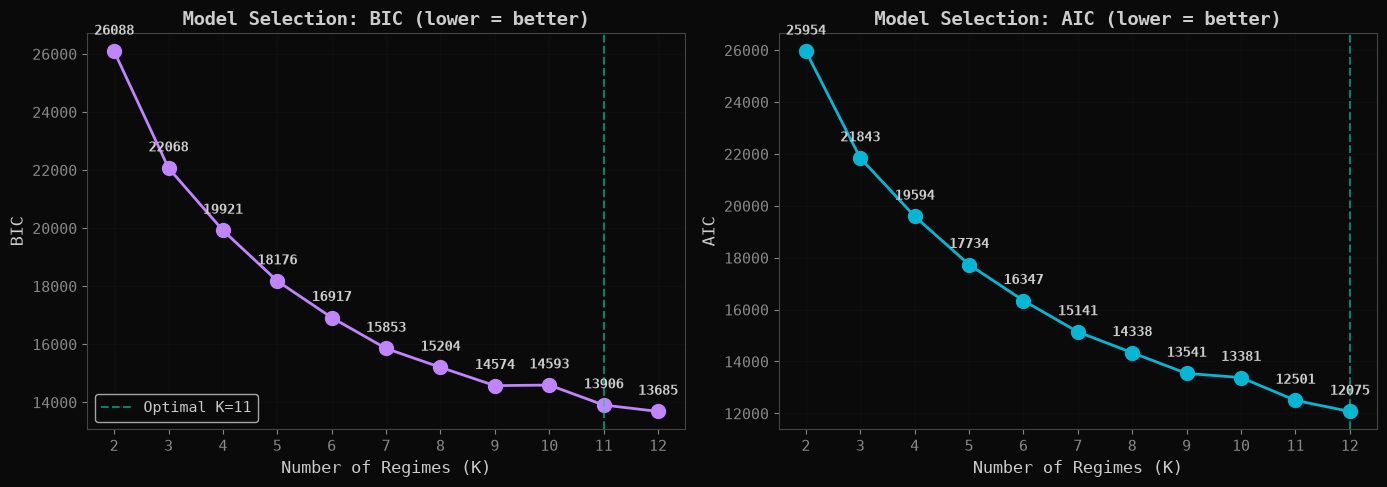

BIC selects K = 11
AIC selects K = 12
  BIC and AIC disagree — BIC penalizes complexity more, so we prefer BIC.


In [8]:
# ─── 4.2 BIC/AIC comparison plot ───

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ks = sorted(model_selection.keys())
bics = [model_selection[k]['bic'] for k in ks]
aics = [model_selection[k]['aic'] for k in ks]

# (a) BIC curve
ax = axes[0]
ax.plot(ks, bics, 'o-', color=COLORS['hmm'], lw=2, markersize=10)
ax.axvline(optimal_K, color=COLORS['accent'], ls='--', lw=1.5, alpha=0.6, label=f'Optimal K={optimal_K}')
for k, b in zip(ks, bics):
    ax.annotate(f'{b:.0f}', (k, b), textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Number of Regimes (K)')
ax.set_ylabel('BIC')
ax.set_title('Model Selection: BIC (lower = better)', fontweight='bold')
ax.set_xticks(ks)
ax.legend()
ax.grid(True, alpha=0.2)

# (b) AIC curve
ax = axes[1]
ax.plot(ks, aics, 'o-', color=COLORS['garch'], lw=2, markersize=10)
optimal_K_aic = min(model_selection, key=lambda k: model_selection[k]['aic'])
ax.axvline(optimal_K_aic, color=COLORS['accent'], ls='--', lw=1.5, alpha=0.6)
for k, a in zip(ks, aics):
    ax.annotate(f'{a:.0f}', (k, a), textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Number of Regimes (K)')
ax.set_ylabel('AIC')
ax.set_title('Model Selection: AIC (lower = better)', fontweight='bold')
ax.set_xticks(ks)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f"BIC selects K = {optimal_K}")
print(f"AIC selects K = {optimal_K_aic}")
if optimal_K != optimal_K_aic:
    print("  BIC and AIC disagree — BIC penalizes complexity more, so we prefer BIC.")


---
<a id="5"></a>
## 5. HMM Calibration & Convergence Diagnostics

We use the BIC-selected model and examine:
- **Transition matrix** — how persistent are the regimes? How likely is switching?
- **Emission parameters** — what are the mean and volatility of each regime?
- **Stationary distribution** — what fraction of time does the market spend in each regime?
- **EM convergence** — did all restarts converge to the same solution?


In [9]:
# ─── 5.1 Extract the best model ───

best_model = model_selection[optimal_K]['model']
K = optimal_K

# Transition matrix
A = best_model.transmat_
print(f"Transition Matrix (K={K}):")
print(pd.DataFrame(A, columns=[f'To R{i+1}' for i in range(K)],
                    index=[f'From R{i+1}' for i in range(K)]).round(4))

# Emission parameters (in standardized space)
print(f"\nEmission Means (standardized):")
for k in range(K):
    print(f"  Regime {k+1}: {best_model.means_[k].round(3)}")

# Un-standardize to interpret economically
means_raw = scaler.inverse_transform(best_model.means_)
print(f"\nEmission Means (raw / interpretable):")
print(f"  {'Regime':<10} {'Ret (daily)':>12} {'Real Vol':>12} {'VIX Δ':>12}")
print(f"  {'-'*48}")
for k in range(K):
    print(f"  R{k+1:<9} {means_raw[k][0]:>12.5f} {means_raw[k][1]:>12.4f} {means_raw[k][2]:>12.5f}")

# Annualize
print(f"\nAnnualized regime characteristics:")
print(f"  {'Regime':<10} {'Ann Ret':>10} {'Ann Vol':>10} {'Persistence':>12} {'E[Duration]':>12}")
print(f"  {'-'*56}")
for k in range(K):
    ann_ret = means_raw[k][0] * 252
    ann_vol = means_raw[k][1]  # already annualized
    persist = A[k, k]
    duration = 1 / (1 - persist) if persist < 1 else np.inf
    print(f"  R{k+1:<9} {ann_ret:>9.1%} {ann_vol:>9.1%} {persist:>12.4f} {duration:>10.1f} days")


Transition Matrix (K=11):
           To R1   To R2   To R3   To R4   To R5   To R6   To R7   To R8  \
From R1   0.9386  0.0000  0.0000  0.0000  0.0042  0.0265  0.0308  0.0000   
From R2   0.0000  0.8757  0.0567  0.0000  0.0091  0.0000  0.0000  0.0017   
From R3   0.0000  0.0071  0.8726  0.0000  0.0687  0.0040  0.0477  0.0000   
From R4   0.0000  0.0000  0.0000  0.9515  0.0000  0.0000  0.0000  0.0000   
From R5   0.0061  0.0000  0.0509  0.0000  0.8563  0.0493  0.0373  0.0000   
From R6   0.0406  0.0000  0.0018  0.0000  0.0435  0.9045  0.0097  0.0000   
From R7   0.0138  0.3465  0.1996  0.0000  0.0631  0.0625  0.2603  0.0127   
From R8   0.0000  0.0056  0.0000  0.0063  0.0000  0.0000  0.0000  0.8927   
From R9   0.0000  0.0000  0.0000  0.0251  0.0000  0.0000  0.0000  0.0465   
From R10  0.0000  0.0000  0.0000  0.0263  0.0000  0.0000  0.0000  0.0000   
From R11  0.0000  0.0631  0.0022  0.0000  0.0000  0.0000  0.0000  0.0501   

           To R9  To R10  To R11  
From R1   0.0000  0.0000  

In [10]:
# ─── 5.2 Sort regimes by volatility (for consistent labeling) ───

# Order regimes by their realized volatility (mean of feature 2)
regime_vol_order = np.argsort(means_raw[:, 1])  # ascending vol

# Create label mapping
regime_labels = {}
_BASE_NAMES = ['Low-Vol', 'Mid-Low-Vol', 'Mid-Vol', 'High-Vol', 'Crisis']
label_names = (_BASE_NAMES + [f'Regime-{i}' for i in range(6, K + 1)])[:K]
for rank, orig_idx in enumerate(regime_vol_order):
    regime_labels[orig_idx] = label_names[rank]

print("Regime labeling (sorted by volatility):")
for orig, label in regime_labels.items():
    ann_ret = means_raw[orig][0] * 252
    ann_vol = means_raw[orig][1]
    print(f"  Original R{orig+1} → {label} (ret={ann_ret:.1%}, vol={ann_vol:.1%})")

# Stationary distribution
eigvals, eigvecs = np.linalg.eig(A.T)
stat_idx = np.argmin(np.abs(eigvals - 1.0))
stationary = np.real(eigvecs[:, stat_idx])
stationary = stationary / stationary.sum()

print(f"\nStationary distribution (long-run time in each regime):")
for k in range(K):
    print(f"  {regime_labels[k]}: {stationary[k]:.1%}")


Regime labeling (sorted by volatility):
  Original R1 → Low-Vol (ret=19.5%, vol=6.0%)
  Original R6 → Mid-Low-Vol (ret=9.9%, vol=7.8%)
  Original R5 → Mid-Vol (ret=20.1%, vol=9.2%)
  Original R3 → High-Vol (ret=18.4%, vol=10.8%)
  Original R7 → Crisis (ret=-326.6%, vol=11.1%)
  Original R2 → Regime-6 (ret=26.6%, vol=13.2%)
  Original R11 → Regime-7 (ret=8.7%, vol=15.5%)
  Original R8 → Regime-8 (ret=-12.5%, vol=18.1%)
  Original R9 → Regime-9 (ret=22.8%, vol=22.0%)
  Original R4 → Regime-10 (ret=-12.2%, vol=29.1%)
  Original R10 → Regime-11 (ret=-0.4%, vol=50.8%)

Stationary distribution (long-run time in each regime):
  Low-Vol: 7.8%
  Regime-6: 12.3%
  High-Vol: 13.1%
  Regime-10: 8.6%
  Mid-Vol: 11.0%
  Mid-Low-Vol: 9.6%
  Crisis: 1.8%
  Regime-8: 10.2%
  Regime-9: 10.1%
  Regime-11: 3.8%
  Regime-7: 11.7%


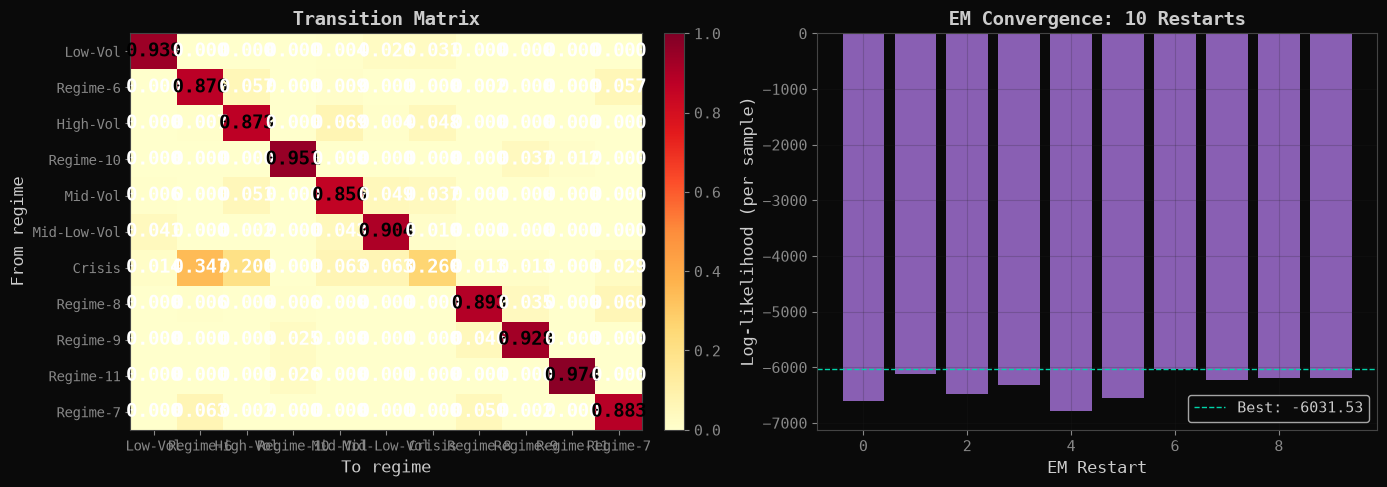

Log-likelihood std across restarts: 230.0025
→ Non-trivial variation across restarts. Multiple local optima exist.


In [11]:
# ─── 5.3 EM convergence diagnostics ───

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Transition matrix heatmap
ax = axes[0]
im = ax.imshow(A, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
for i in range(K):
    for j in range(K):
        color = 'black' if A[i, j] > 0.5 else 'white'
        ax.text(j, i, f'{A[i,j]:.3f}', ha='center', va='center', fontsize=14, color=color, fontweight='bold')
ax.set_xticks(range(K))
ax.set_xticklabels([regime_labels[i] for i in range(K)], fontsize=10)
ax.set_yticks(range(K))
ax.set_yticklabels([regime_labels[i] for i in range(K)], fontsize=10)
ax.set_xlabel('To regime')
ax.set_ylabel('From regime')
ax.set_title('Transition Matrix', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# (b) Log-likelihood across EM restarts
ax = axes[1]
conv_log = model_selection[optimal_K]['convergence']
scores = [c['score'] for c in conv_log if not np.isnan(c.get('score', np.nan))]
ax.bar(range(len(scores)), scores, color=COLORS['hmm'], alpha=0.7)
ax.axhline(max(scores), color=COLORS['accent'], ls='--', lw=1, label=f'Best: {max(scores):.2f}')
ax.set_xlabel('EM Restart')
ax.set_ylabel('Log-likelihood (per sample)')
ax.set_title(f'EM Convergence: {len(scores)} Restarts', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Check if restarts agree
score_std = np.std(scores)
print(f"Log-likelihood std across restarts: {score_std:.4f}")
if score_std < 0.01:
    print("→ All restarts converge to similar solutions. Model is stable.")
else:
    print("→ Non-trivial variation across restarts. Multiple local optima exist.")


---
<a id="6"></a>
## 6. State Inference: Forward-Backward & Viterbi

We compute:
- **Smoothed state probabilities** $\gamma_t(k) = P(S_t = k | Y_{1:T})$ via the forward-backward algorithm
- **Most-likely state sequence** $S^* = \arg\max P(S_{1:T} | Y_{1:T})$ via the Viterbi algorithm


In [12]:
# ─── 6.1 State probabilities and Viterbi path ───

# FULL-SAMPLE — descriptive only, never for trading decisions
X_full = features_scaled.values

# Smoothed state probabilities (forward-backward)
state_probs = best_model.predict_proba(X_full)

# Viterbi most-likely path
viterbi_states = best_model.predict(X_full)

# Create labeled regime series
regime_series = pd.Series(
    [regime_labels[s] for s in viterbi_states],
    index=features_scaled.index, name='regime'
)

state_prob_df = pd.DataFrame(
    state_probs, index=features_scaled.index,
    columns=[regime_labels[k] for k in range(K)]
)

print(f"Regime classification summary:")
print(regime_series.value_counts())
print(f"\nRegime transitions: {(regime_series != regime_series.shift()).sum() - 1}")
print(f"Average regime duration: {len(regime_series) / ((regime_series != regime_series.shift()).sum() - 1):.1f} days")


Regime classification summary:
regime
High-Vol       817
Regime-6       791
Regime-9       704
Regime-7       680
Mid-Vol        667
Regime-8       661
Regime-10      630
Mid-Low-Vol    555
Low-Vol        410
Regime-11      230
Crisis         122
Name: count, dtype: int64

Regime transitions: 685
Average regime duration: 9.1 days


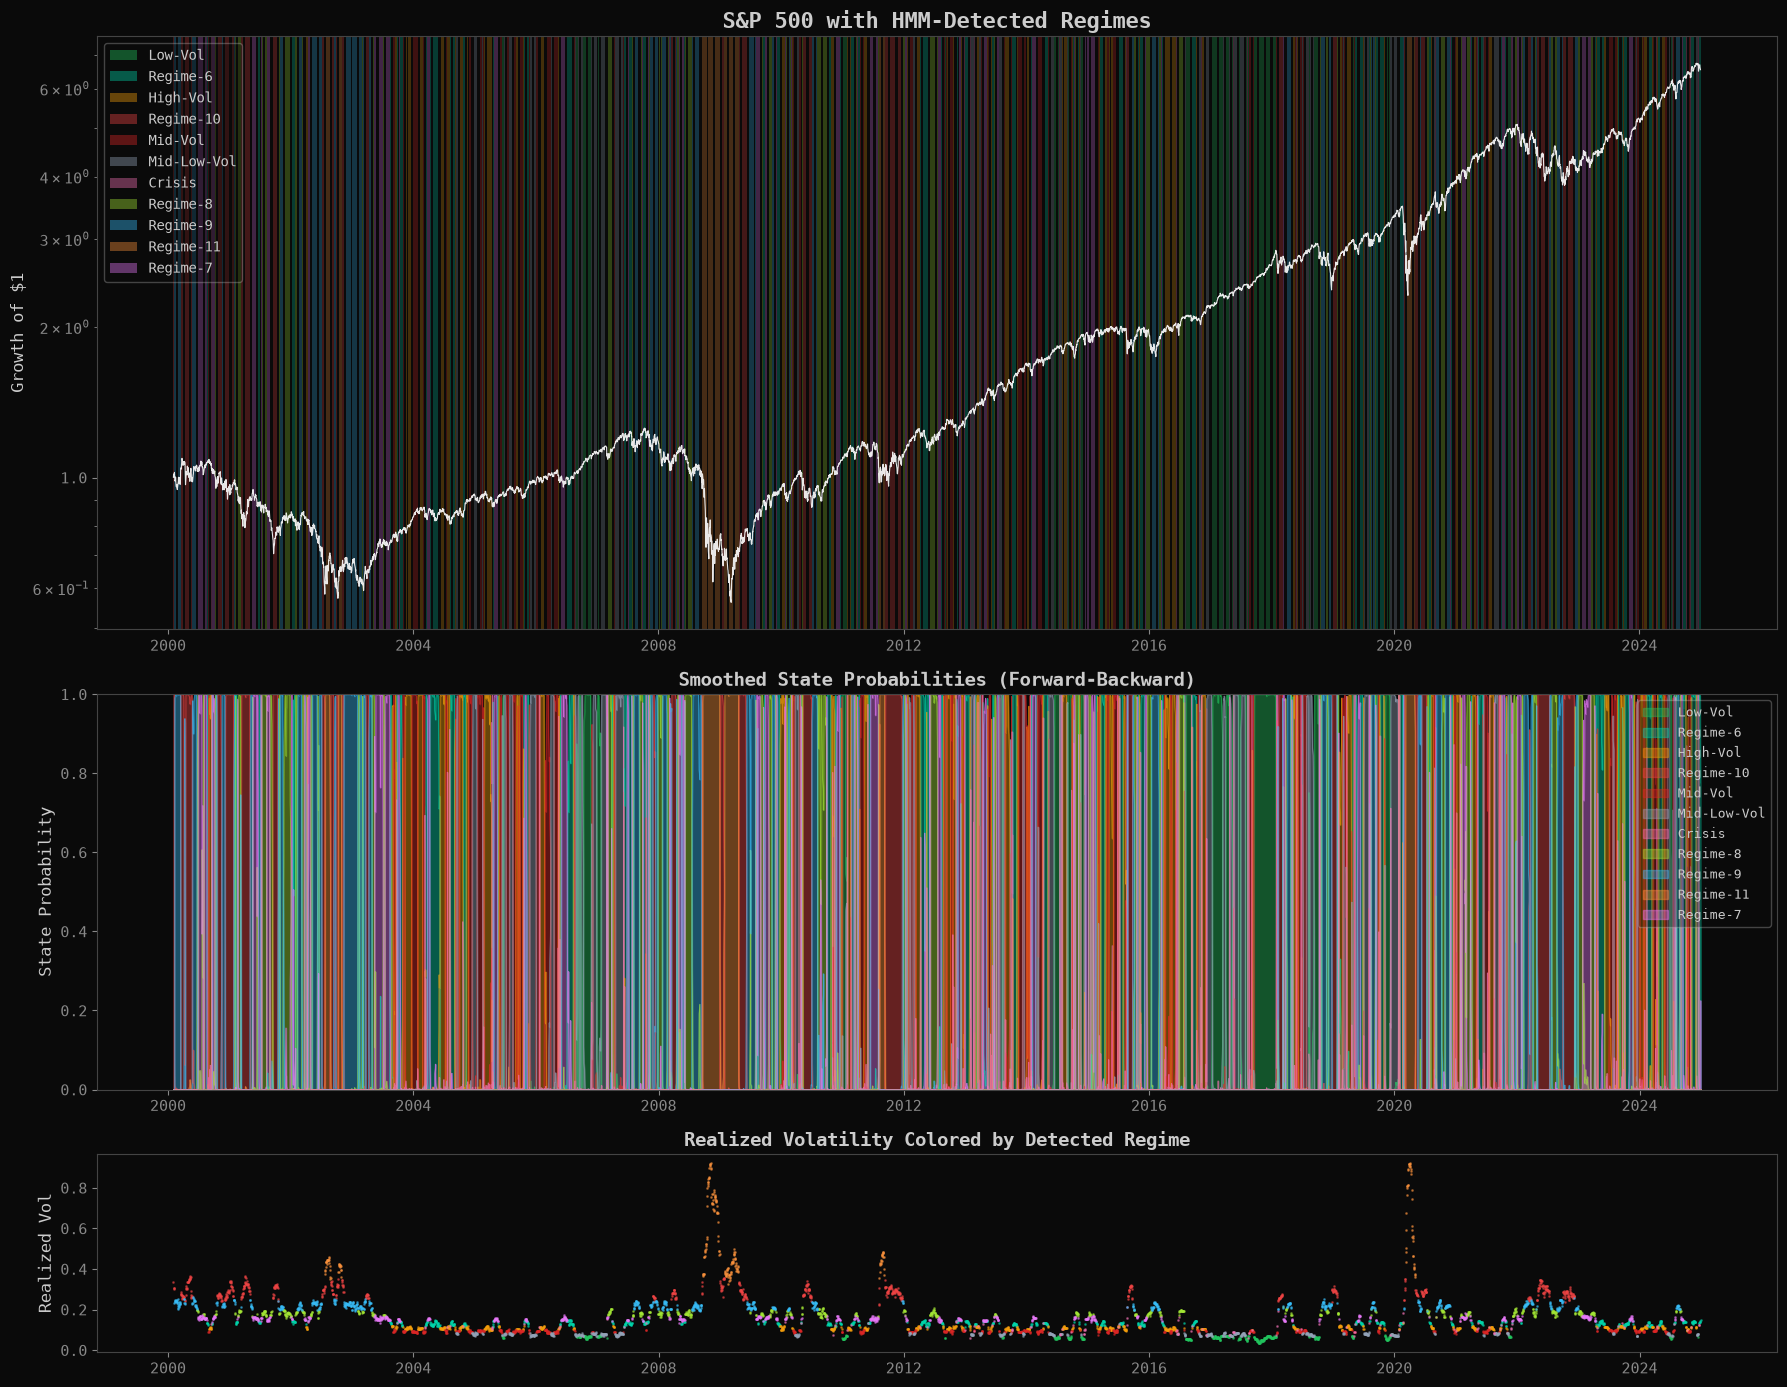

→ The HMM identifies regimes that align with known market conditions:
  Low-vol corresponds to bull markets, High-vol/Crisis to GFC and COVID.


In [13]:
# ─── 6.2 THE SIGNATURE PLOT: Regime timeline overlaid on S&P 500 ───

fig, axes = plt.subplots(3, 1, figsize=(18, 14), gridspec_kw={'height_ratios': [3, 2, 1]})

# (a) S&P 500 price with regime background coloring
ax = axes[0]
cum = (1 + np.expm1(spy_ret.reindex(features_scaled.index))).cumprod()  # G-2: compound simple returns
ax.plot(cum.index, cum.values, color='white', lw=0.8, alpha=0.9)

# Color background by regime
for k in range(K):
    label = regime_labels[k]
    color = REGIME_COLORS[k] if k < len(REGIME_COLORS) else '#888888'
    mask = viterbi_states == k
    dates = features_scaled.index[mask]
    for d in dates:
        ax.axvspan(d, d + pd.Timedelta(days=1), alpha=0.25, color=color, linewidth=0)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=REGIME_COLORS[k], alpha=0.4, label=regime_labels[k]) for k in range(K)]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.3)

ax.set_ylabel('Growth of $1')
ax.set_title('S&P 500 with HMM-Detected Regimes', fontsize=16, fontweight='bold')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())

# (b) State probabilities (stacked area)
ax = axes[1]
for k in range(K):
    label = regime_labels[k]
    color = REGIME_COLORS[k] if k < len(REGIME_COLORS) else '#888888'
    ax.fill_between(state_prob_df.index, 0, state_prob_df[label],
                     alpha=0.4, color=color, label=label)
    ax.plot(state_prob_df.index, state_prob_df[label], lw=0.5, color=color, alpha=0.6)

ax.set_ylabel('State Probability')
ax.set_title('Smoothed State Probabilities (Forward-Backward)', fontweight='bold')
ax.set_ylim(0, 1)
ax.legend(loc='upper right', fontsize=9, framealpha=0.3)

# (c) Realized volatility colored by regime
ax = axes[2]
for k in range(K):
    mask = viterbi_states == k
    dates = features_raw.index[features_raw.index.isin(features_scaled.index[mask])]
    vals = features_raw.loc[dates, 'realized_vol']
    color = REGIME_COLORS[k] if k < len(REGIME_COLORS) else '#888888'
    ax.scatter(dates, vals, s=1, alpha=0.5, color=color)

ax.set_ylabel('Realized Vol')
ax.set_title('Realized Volatility Colored by Detected Regime', fontweight='bold')

plt.tight_layout()
plt.show()

print("→ The HMM identifies regimes that align with known market conditions:")
print("  Low-vol corresponds to bull markets, High-vol/Crisis to GFC and COVID.")


---
<a id="7"></a>
## 7. Regime Characterization

For each detected regime, we compute statistics that tell us whether the regimes are economically meaningful — not just statistically distinct, but interpretable.


In [14]:
# ─── 7.1 Regime statistics table ───

spy_aligned = np.expm1(spy_ret.reindex(features_scaled.index))  # G-2: regime stats compound simple returns

print(f"{'='*90}")
print(f"REGIME CHARACTERIZATION")
print(f"{'='*90}")
print(f"{'Regime':<12} {'Days':>6} {'%Time':>7} {'Ann Ret':>9} {'Ann Vol':>9} {'Sharpe':>8} "
      f"{'MaxDD':>8} {'Skew':>7} {'Kurt':>7} {'E[Dur]':>8}")
print("-" * 90)

regime_stats = {}
for k in range(K):
    label = regime_labels[k]
    mask = viterbi_states == k
    dates = features_scaled.index[mask]
    rets = spy_aligned.loc[dates].dropna()
    
    n_days = len(rets)
    pct_time = n_days / len(spy_aligned) * 100
    ann_ret = rets.mean() * 252
    ann_vol = rets.std() * np.sqrt(252)
    sharpe = (rets.mean() / rets.std() * np.sqrt(252)) if rets.std() > 0 else 0
    cum = (1 + rets).cumprod()
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min() if len(cum) > 0 else 0
    skew = rets.skew()
    kurt = rets.kurtosis()
    persist = A[k, k]
    e_dur = 1 / (1 - persist) if persist < 1 else np.inf
    
    regime_stats[label] = {
        'n_days': n_days, 'pct_time': pct_time, 'ann_ret': ann_ret,
        'ann_vol': ann_vol, 'sharpe': sharpe, 'max_dd': max_dd,
        'skew': skew, 'kurtosis': kurt, 'e_duration': e_dur,
    }
    
    print(f"{label:<12} {n_days:>6} {pct_time:>6.1f}% {ann_ret:>8.1%} {ann_vol:>8.1%} {sharpe:>8.3f} "
          f"{max_dd:>7.1%} {skew:>7.2f} {kurt:>7.1f} {e_dur:>7.1f}d")


REGIME CHARACTERIZATION
Regime         Days   %Time   Ann Ret   Ann Vol   Sharpe    MaxDD    Skew    Kurt   E[Dur]
------------------------------------------------------------------------------------------
Low-Vol         410    6.5%    24.0%     6.3%    3.815   -2.8%    0.22     0.1    16.3d
Regime-6        791   12.6%    31.3%    11.8%    2.665  -10.3%    0.00     0.1     8.0d
High-Vol        817   13.0%    27.9%    10.1%    2.773   -4.7%   -0.02     0.0     7.8d
Regime-10       630   10.1%     0.6%    29.2%    0.020  -39.8%   -0.12     0.4    20.6d
Mid-Vol         667   10.6%    19.3%     9.2%    2.099   -5.5%   -0.08     0.2     7.0d
Mid-Low-Vol     555    8.9%    12.6%     7.5%    1.678   -6.1%   -0.28     0.1    10.5d
Crisis          122    1.9%  -353.9%    17.5%  -20.269  -81.9%    0.32     0.8     1.4d
Regime-8        661   10.5%    -1.7%    18.1%   -0.091  -46.3%   -0.37     0.1     9.3d
Regime-9        704   11.2%    20.1%    21.1%    0.953  -23.1%   -0.10    -0.2    14.0d
Re

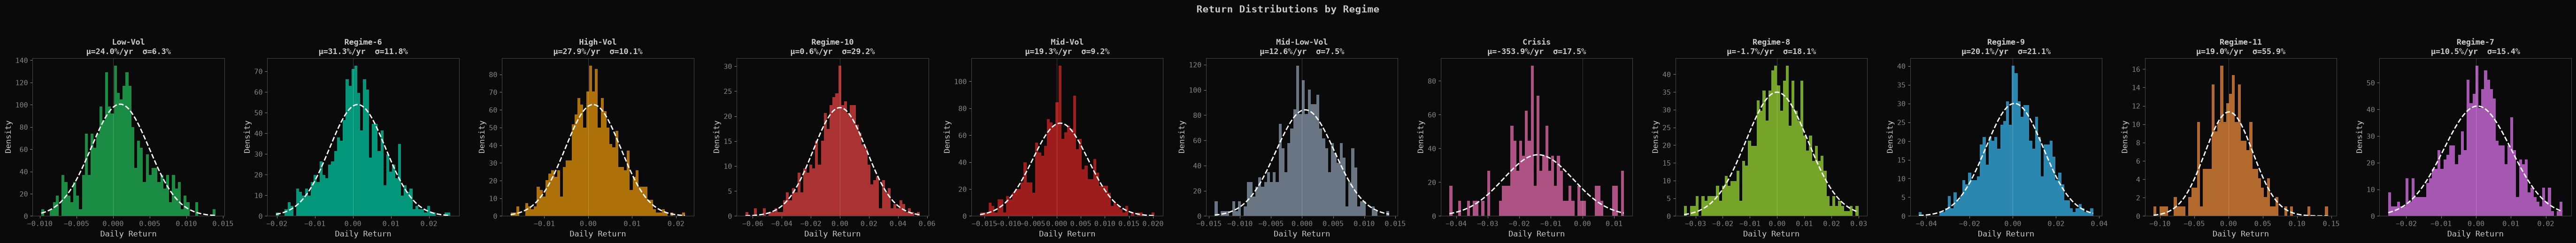

In [15]:
# ─── 7.2 Regime-conditioned distributions ───

fig, axes = plt.subplots(1, K, figsize=(5*K, 5))
if K == 1:
    axes = [axes]

for k in range(K):
    ax = axes[k]
    label = regime_labels[k]
    mask = viterbi_states == k
    rets = spy_aligned.loc[features_scaled.index[mask]].dropna()
    
    color = REGIME_COLORS[k % len(REGIME_COLORS)]
    ax.hist(rets, bins=60, density=True, alpha=0.7, color=color, edgecolor='none')
    
    # Overlay fitted Gaussian
    x = np.linspace(rets.min(), rets.max(), 200)
    ax.plot(x, stats.norm.pdf(x, rets.mean(), rets.std()), color='white', lw=2, ls='--')
    
    ax.set_title(f'{label}\nμ={rets.mean()*252:.1%}/yr  σ={rets.std()*np.sqrt(252):.1%}',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Density')
    ax.axvline(0, color='white', lw=0.5, alpha=0.3)

plt.suptitle('Return Distributions by Regime', y=1.03, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


---
<a id="8"></a>
## 8. Volatility Forecasting: HMM vs Benchmarks

A key test: does the HMM's current-regime volatility $\sigma_k$ predict next-period realized volatility better than:
1. **Rolling 21-day historical vol**
2. **GARCH(1,1)**
3. **VIX-implied volatility**

If the HMM can't beat these simpler methods at volatility forecasting, the regime detection may just be a complicated way to measure rolling volatility — Failure Mode #6 in our documentation.


In [16]:
# ─── 8.1 Volatility forecasts ───

# P3-6 fix: the forecast at time t may only use data through t, so it is
# built from FILTERED probabilities (forward pass — common/hmm_filter.py).
# The smoothed posteriors condition on the entire sample (hindsight); they
# stay in the table, labeled, to show how much hindsight flatters the model.
import sys
from pathlib import Path as _Path
_REPO_ROOT = str(_Path('../../..').resolve())  # same relative root the data/ cache uses
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)
from common.hmm_filter import filtered_probabilities

regime_vols = means_raw[:, 1]  # annualized vol per regime
filt_probs = filtered_probabilities(best_model, X_full)
hmm_vol_filt = pd.Series(filt_probs @ regime_vols, index=features_scaled.index)
# FULL-SAMPLE — descriptive only, never for trading decisions:
hmm_vol_smooth = pd.Series(state_probs @ regime_vols, index=features_scaled.index)

# Benchmark 1: Rolling 21-day historical vol
rolling_vol = features_raw['realized_vol']

# Benchmark 2: Simple GARCH proxy (EWMA vol)
ewma_vol = spy_ret.reindex(features_scaled.index).ewm(span=21).std() * np.sqrt(252)

# Benchmark 3: VIX (already in annualized vol terms, divide by 100 if needed)
vix_forecast = vix.reindex(features_scaled.index).ffill() / 100  # VIX is in percentage points

# Realized vol for next 21 days (what we're forecasting)
future_vol = spy_ret.reindex(features_scaled.index).rolling(21).std().shift(-21) * np.sqrt(252)

# Align everything
forecasts = pd.DataFrame({
    'realized_next': future_vol,
    'hmm_filt': hmm_vol_filt,
    'hmm_smooth': hmm_vol_smooth,
    'rolling': rolling_vol,
    'ewma': ewma_vol,
    'vix': vix_forecast,
}).dropna()

# OOS only
oos_mask = forecasts.index >= CONFIG['oos_start']
forecasts_oos = forecasts[oos_mask]

# Compute forecast errors
print("Volatility Forecasting — OOS Performance:")
print(f"{'Method':<15} {'RMSE':>10} {'MAE':>10} {'Corr':>10}")
print("-" * 47)

print("(hmm_smooth is graded with HINDSIGHT — shown only to size the flattery gap)")
for method in ['hmm_filt', 'hmm_smooth', 'rolling', 'ewma', 'vix']:
    resid = forecasts_oos[method] - forecasts_oos['realized_next']
    rmse = np.sqrt((resid**2).mean())
    mae = resid.abs().mean()
    corr = forecasts_oos[method].corr(forecasts_oos['realized_next'])
    print(f"{method:<15} {rmse:>10.4f} {mae:>10.4f} {corr:>10.4f}")


Volatility Forecasting — OOS Performance:
Method                RMSE        MAE       Corr
-----------------------------------------------
(hmm_smooth is graded with HINDSIGHT — shown only to size the flattery gap)
hmm_filt            0.1005     0.0610     0.4788
hmm_smooth          0.0991     0.0602     0.4944
rolling             0.1098     0.0636     0.4808
ewma                0.1038     0.0608     0.5264
vix                 0.0965     0.0666     0.5683


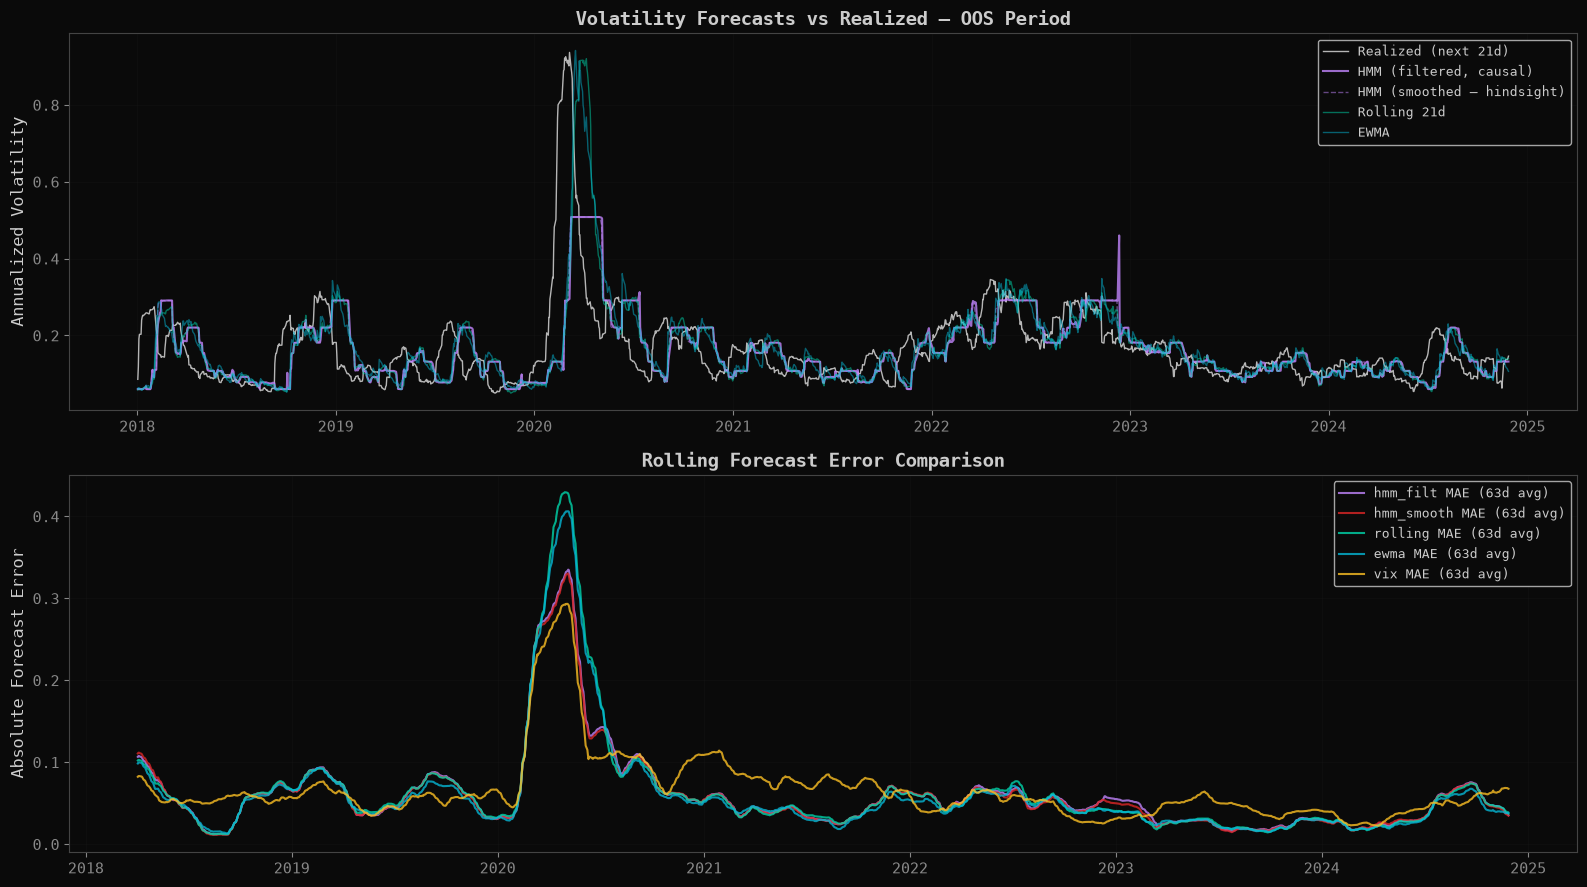

In [17]:
# ─── 8.2 Vol forecast visualization ───

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# (a) Vol forecasts vs realized
ax = axes[0]
ax.plot(forecasts_oos.index, forecasts_oos['realized_next'], color='white', lw=1, alpha=0.7, label='Realized (next 21d)')
ax.plot(forecasts_oos.index, forecasts_oos['hmm_filt'], color=COLORS['hmm'], lw=1.5, alpha=0.8, label='HMM (filtered, causal)')
ax.plot(forecasts_oos.index, forecasts_oos['hmm_smooth'], color=COLORS['hmm'], lw=1.0, ls='--', alpha=0.5, label='HMM (smoothed — hindsight)')
ax.plot(forecasts_oos.index, forecasts_oos['rolling'], color=COLORS['accent'], lw=1, alpha=0.5, label='Rolling 21d')
ax.plot(forecasts_oos.index, forecasts_oos['ewma'], color=COLORS['garch'], lw=1, alpha=0.5, label='EWMA')
ax.set_ylabel('Annualized Volatility')
ax.set_title('Volatility Forecasts vs Realized — OOS Period', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# (b) Forecast error comparison
ax = axes[1]
for method, color in [('hmm_filt', COLORS['hmm']), ('hmm_smooth', COLORS['crisis']),
                       ('rolling', COLORS['accent']),
                       ('ewma', COLORS['garch']), ('vix', COLORS['vix_switch'])]:
    error = (forecasts_oos[method] - forecasts_oos['realized_next']).abs()
    ax.plot(error.rolling(63).mean().index, error.rolling(63).mean().values,
            color=color, lw=1.5, alpha=0.8, label=f'{method} MAE (63d avg)')

ax.set_ylabel('Absolute Forecast Error')
ax.set_title('Rolling Forecast Error Comparison', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


---
<a id="9"></a>
## 9. Regime-Aware Portfolio Construction

<a id="10"></a>
## 10. Benchmark Strategies

<a id="11"></a>
## 11. Rolling Out-of-Sample Backtest

The regime-switching strategy: **equities (SPY) in Low-Vol regime, defensive (TLT) in High-Vol/Crisis regime, 50/50 blend in Mid-Vol.** At each monthly rebalance, the HMM is re-fitted on trailing data, and the current regime probability determines the allocation.

Benchmarks: Buy-and-Hold SPY, 60/40, VIX-based switching, EWMA vol switching.


In [18]:
# ─── 11.1 Rolling OOS backtest ───

print("=" * 60)
print("RUNNING REGIME-SWITCHING BACKTEST")
print("=" * 60)
t0 = time.time()
bt = run_regime_backtest(spy_ret, tlt_ret, features_scaled, features_raw,
                         vix, CONFIG, n_regimes=optimal_K)  # explicit params (2.2)
print(f"\nCompleted in {time.time()-t0:.1f}s")


RUNNING REGIME-SWITCHING BACKTEST


  Rebalance 1/197 at 2008-07-16 | equity alloc: 0.50


Model is not converging.  Current: -1892.2373025310817 is not greater than -1873.5125278062283. Delta is -18.724774724853432


  Rebalance 21/197 at 2010-03-17 | equity alloc: 0.50


Model is not converging.  Current: -1539.1671244131476 is not greater than -1519.3212065369696. Delta is -19.845917876177964


...

Model is not converging.  Current: -1707.496105552309 is not greater than -1690.1982115722244. Delta is -17.29789398008461


  Rebalance 161/197 at 2021-11-17 | equity alloc: 1.00


  Rebalance 181/197 at 2023-07-24 | equity alloc: 0.50


Model is not converging.  Current: -2561.6494785521154 is not greater than -2549.146688758532. Delta is -12.50278979358336



Completed in 156.5s


---
<a id="12"></a>
## 12. Performance Evaluation


In [19]:
# ─── 12.1 Metrics ───

# ROADMAP 2.1: metrics via common/metrics.py — P3's key names match
# common.summary exactly, so this is a pure drop-in.
from common.metrics import summary as compute_metrics

strat_labels = {
    'hmm_switch': 'HMM Regime Switching', 'buy_hold': 'Buy & Hold SPY',
    'sixty_forty': '60/40 Portfolio', 'vix_switch': 'VIX-Based Switching',
    'vol_switch': 'Rolling Vol Switching',
}

for period_name, mask_fn in [('Full', lambda r: r),
                              ('IS', lambda r: r[r.index <= CONFIG['is_end']]),
                              ('OOS', lambda r: r[r.index >= CONFIG['oos_start']])]:
    print(f"\n{'='*105}")
    print(f"PERFORMANCE — {period_name}")
    print(f"{'='*105}")
    print(f"{'Strategy':<24} {'Return':>8} {'Vol':>8} {'Sharpe':>8} {'SR 95% CI':>18} {'MaxDD':>8} {'Calmar':>8} {'Sortino':>8}")
    print("-" * 105)
    
    for s in ['hmm_switch', 'buy_hold', 'sixty_forty', 'vix_switch', 'vol_switch']:
        r = mask_fn(bt[s]['returns'])
        m = compute_metrics(r)
        ci = f"[{m.get('sharpe_ci_lo',0):.2f}, {m.get('sharpe_ci_hi',0):.2f}]"
        print(f"{strat_labels[s]:<24} {m['ann_ret']:>7.2%} {m['ann_vol']:>7.2%} {m['sharpe']:>8.3f} "
              f"{ci:>18} {m['max_dd']:>7.2%} {m['calmar']:>8.3f} {m['sortino']:>8.3f}")



PERFORMANCE — Full
Strategy                   Return      Vol   Sharpe          SR 95% CI    MaxDD   Calmar  Sortino
---------------------------------------------------------------------------------------------------------
HMM Regime Switching       9.49%  11.31%    0.618       [0.09, 1.15] -29.70%    0.320    0.815
Buy & Hold SPY            13.42%  19.97%    0.547       [0.03, 1.07] -47.17%    0.284    0.659
60/40 Portfolio            9.62%  11.55%    0.616       [0.09, 1.14] -27.24%    0.353    0.790
VIX-Based Switching        9.30%  14.81%    0.459      [-0.05, 0.97] -39.76%    0.234    0.556
Rolling Vol Switching     10.13%  14.83%    0.515      [-0.00, 1.03] -36.59%    0.277    0.627

PERFORMANCE — IS
Strategy                   Return      Vol   Sharpe          SR 95% CI    MaxDD   Calmar  Sortino
---------------------------------------------------------------------------------------------------------
HMM Regime Switching      10.37%  10.65%    0.738       [0.02, 1.46] -18.55%   

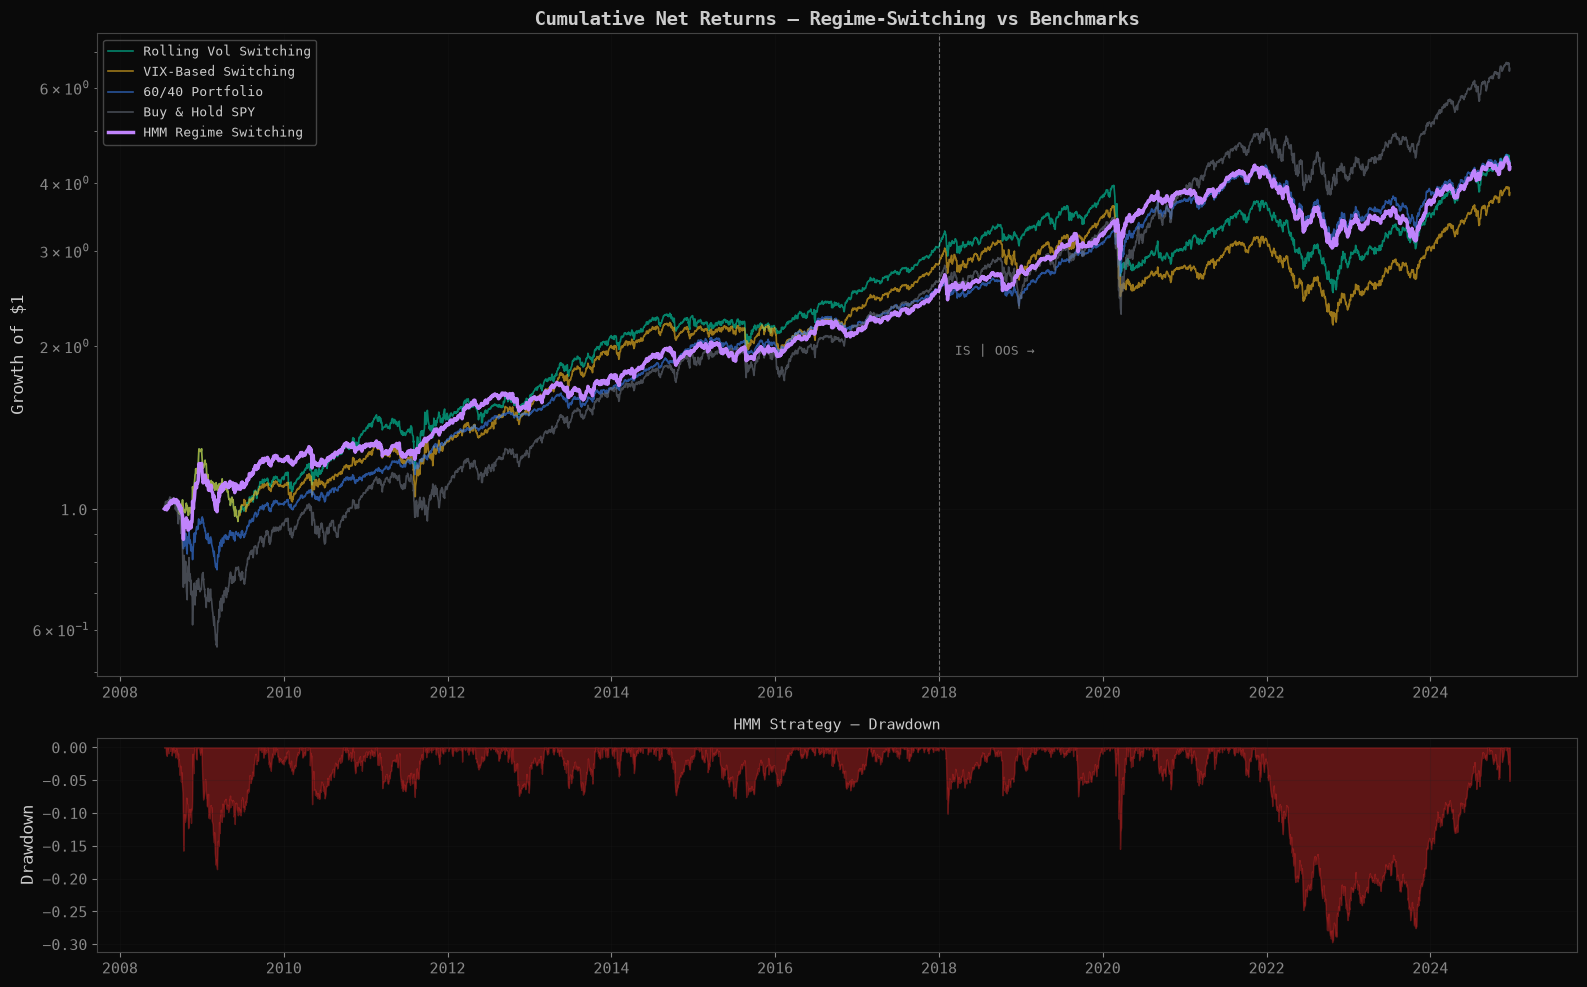

In [20]:
# ─── 12.2 Cumulative return plot ───

fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})

color_map = {'hmm_switch': COLORS['hmm'], 'buy_hold': COLORS['buyhold'],
             'sixty_forty': COLORS['sixty_forty'], 'vix_switch': COLORS['vix_switch'],
             'vol_switch': COLORS['accent']}

ax = axes[0]
for s in ['vol_switch', 'vix_switch', 'sixty_forty', 'buy_hold', 'hmm_switch']:
    ret = bt[s]['returns']
    cum = (1 + ret).cumprod()
    lw = 2.5 if s == 'hmm_switch' else 1.2
    alpha = 1.0 if s == 'hmm_switch' else 0.6
    ax.plot(cum.index, cum.values, color=color_map[s], lw=lw, alpha=alpha, label=strat_labels[s])

ax.axvline(pd.Timestamp(CONFIG['is_end']), color='white', lw=0.8, ls='--', alpha=0.4)
ax.text(pd.Timestamp(CONFIG['is_end']), 0.5, '  IS | OOS →', fontsize=9, color='white', alpha=0.5,
        transform=ax.get_xaxis_transform())
ax.set_title('Cumulative Net Returns — Regime-Switching vs Benchmarks', fontsize=14, fontweight='bold')
ax.set_ylabel('Growth of $1')
ax.legend(loc='upper left', fontsize=9, framealpha=0.3)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.grid(True, alpha=0.2)

# Drawdown
ax = axes[1]
ret = bt['hmm_switch']['returns']
cum = (1 + ret).cumprod()
dd = (cum - cum.cummax()) / cum.cummax()
ax.fill_between(dd.index, 0, dd.values, color=COLORS['crisis'], alpha=0.4)
ax.set_title('HMM Strategy — Drawdown', fontsize=11)
ax.set_ylabel('Drawdown')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


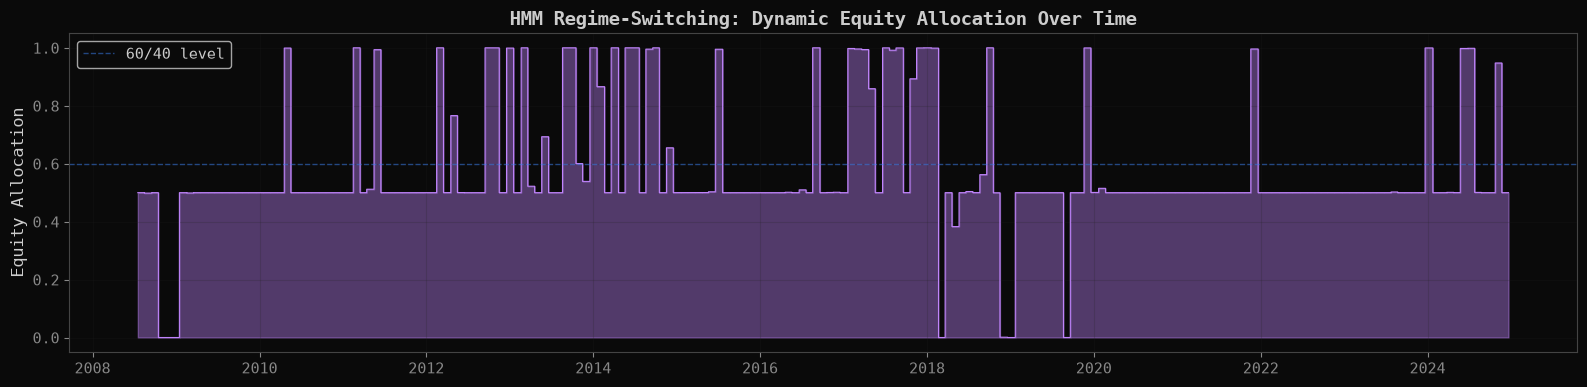

Equity allocation statistics:
  Mean: 57.8%
  Time at 100% equity: 16.8%
  Time at 0% equity (fully defensive): 3.6%


In [21]:
# ─── 12.3 Equity allocation over time ───

if bt['hmm_switch'].get('alloc_equity'):
    alloc_series = pd.Series(
        bt['hmm_switch']['alloc_equity'],
        index=bt['hmm_switch']['dates']
    )
    
    fig, ax = plt.subplots(figsize=(16, 4))
    ax.fill_between(alloc_series.index, 0, alloc_series.values, 
                     color=COLORS['hmm'], alpha=0.4, step='post')
    ax.plot(alloc_series.index, alloc_series.values, 
            color=COLORS['hmm'], lw=0.8, drawstyle='steps-post')
    ax.axhline(0.6, color=COLORS['sixty_forty'], ls='--', lw=1, alpha=0.5, label='60/40 level')
    ax.set_ylabel('Equity Allocation')
    ax.set_title('HMM Regime-Switching: Dynamic Equity Allocation Over Time', fontweight='bold')
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Equity allocation statistics:")
    print(f"  Mean: {alloc_series.mean():.1%}")
    print(f"  Time at 100% equity: {(alloc_series > 0.95).mean():.1%}")
    print(f"  Time at 0% equity (fully defensive): {(alloc_series < 0.05).mean():.1%}")


---
<a id="13"></a>
## 13. Sensitivity Analysis


In [22]:
# ─── 13.1 Regime latency analysis ───
# Key question: does the HMM detect crises BEFORE or AFTER the drawdown?

print("Regime Latency Analysis:")
print("How quickly does the HMM detect regime changes?\n")

# Find crisis-like periods where realized vol spiked
vol_series = features_raw['realized_vol'].reindex(features_scaled.index)
vol_spikes = vol_series[vol_series > vol_series.quantile(0.95)]

# For each spike, check when the HMM first flagged high-vol
# Use the highest-vol regime
high_vol_regime = regime_vol_order[-1]
high_vol_probs = state_probs[:, high_vol_regime]
high_vol_prob_series = pd.Series(high_vol_probs, index=features_scaled.index)

# Major events
events = [
    ('GFC start', '2008-09-15'),
    ('COVID crash', '2020-02-24'),
    ('2022 selloff', '2022-01-24'),
]

for event_name, event_date in events:
    ed = pd.Timestamp(event_date)
    if ed not in high_vol_prob_series.index:
        # Find nearest date
        ed = high_vol_prob_series.index[high_vol_prob_series.index.searchsorted(ed)]
    
    # Look at HMM probability 30 days before and after
    window_start = ed - pd.Timedelta(days=45)
    window_end = ed + pd.Timedelta(days=15)
    window_probs = high_vol_prob_series[window_start:window_end]
    
    # When did probability first exceed 50%?
    first_alert = window_probs[window_probs > 0.5].index[0] if (window_probs > 0.5).any() else None
    
    if first_alert:
        lag = (first_alert - ed).days
        print(f"  {event_name} ({event_date}): HMM flagged high-vol {lag:+d} days relative to event")
    else:
        print(f"  {event_name} ({event_date}): HMM did not flag high-vol in ±45 day window")

print("\n→ Negative lag = HMM detected before the event (early warning)")
print("  Positive lag = HMM detected after (lagging indicator)")
print("  The HMM uses realized vol as input, so some lag is structural.")


Regime Latency Analysis:
How quickly does the HMM detect regime changes?

  GFC start (2008-09-15): HMM flagged high-vol +4 days relative to event
  COVID crash (2020-02-24): HMM flagged high-vol +11 days relative to event
  2022 selloff (2022-01-24): HMM did not flag high-vol in ±45 day window

→ Negative lag = HMM detected before the event (early warning)
  Positive lag = HMM detected after (lagging indicator)
  The HMM uses realized vol as input, so some lag is structural.


In [23]:
# ─── 13.2 Number of regimes sensitivity ───

print("\nSensitivity to Number of Regimes (in-sample):")
print(f"{'K':>4} {'BIC':>12} {'AIC':>12} {'LogLik':>12} {'Params':>8}")
print("-" * 50)

for K_test in sorted(model_selection.keys()):
    ms = model_selection[K_test]
    print(f"{K_test:>4} {ms['bic']:>12.0f} {ms['aic']:>12.0f} {ms['loglik']:>12.0f} {ms['n_params']:>8}")

# Transition frequency sensitivity
if bt['hmm_switch'].get('alloc_equity'):
    alloc = np.array(bt['hmm_switch']['alloc_equity'])
    transitions = (np.abs(np.diff(alloc)) > 0.1).sum()
    print(f"\nPortfolio regime transitions (alloc change > 10%): {transitions}")
    print(f"Average holding period: {len(alloc) / max(transitions, 1):.0f} days")
    
    # Estimated turnover cost
    turnover = np.sum(np.abs(np.diff(alloc)))
    annual_turnover = turnover / (len(alloc) / 252)
    print(f"Annual turnover: {annual_turnover:.2f}")
    print(f"Annual TC drag (at {CONFIG['c_prop']*10000:.0f} bps): {annual_turnover * CONFIG['c_prop'] * 10000:.1f} bps")



Sensitivity to Number of Regimes (in-sample):
   K          BIC          AIC       LogLik   Params
--------------------------------------------------
   2        26088        25954       -12956       21
   3        22068        21843       -10887       35
   4        19921        19594        -9746       51
   5        18176        17734        -8798       69
   6        16917        16347        -8084       89
   7        15853        15141        -7460      111
   8        15204        14338        -7034      135
   9        14574        13541        -6610      161
  10        14593        13381        -6502      189
  11        13906        12501        -6032      219
  12        13685        12075        -5787      251

Portfolio regime transitions (alloc change > 10%): 64
Average holding period: 65 days
Annual turnover: 1.73
Annual TC drag (at 5 bps): 8.6 bps


---
<a id="14"></a>
## 14. Failure Mode Analysis


In [24]:
# ─── 14.1 Honest assessment ───

print("=" * 60)
print("HONEST ASSESSMENT")
print("=" * 60)

hmm_oos = compute_metrics(bt['hmm_switch']['returns'][bt['hmm_switch']['returns'].index >= CONFIG['oos_start']])
bh_oos = compute_metrics(bt['buy_hold']['returns'][bt['buy_hold']['returns'].index >= CONFIG['oos_start']])
sf_oos = compute_metrics(bt['sixty_forty']['returns'][bt['sixty_forty']['returns'].index >= CONFIG['oos_start']])
vix_oos = compute_metrics(bt['vix_switch']['returns'][bt['vix_switch']['returns'].index >= CONFIG['oos_start']])

print(f"\nOOS Net Sharpe Ratios:")
print(f"  HMM Switching:    {hmm_oos['sharpe']:.3f}  CI: [{hmm_oos['sharpe_ci_lo']:.3f}, {hmm_oos['sharpe_ci_hi']:.3f}]")
print(f"  Buy & Hold:       {bh_oos['sharpe']:.3f}")
print(f"  60/40:            {sf_oos['sharpe']:.3f}")
print(f"  VIX Switching:    {vix_oos['sharpe']:.3f}")

print(f"\nOOS Maximum Drawdown:")
print(f"  HMM Switching:    {hmm_oos['max_dd']:.2%}")
print(f"  Buy & Hold:       {bh_oos['max_dd']:.2%}")

# Failure mode check: is HMM just tracking VIX?
hmm_alloc = pd.Series(bt['hmm_switch']['alloc_equity'], index=bt['hmm_switch']['dates'])
vix_alloc_proxy = vix.reindex(hmm_alloc.index).ffill()

# Negate VIX for correlation (high VIX = low equity)
if len(hmm_alloc) > 0 and len(vix_alloc_proxy.dropna()) > 0:
    corr_with_vix = hmm_alloc.corr(-vix_alloc_proxy.dropna())
    print(f"\nCorrelation between HMM allocation and (-VIX): {corr_with_vix:.3f}")
    if abs(corr_with_vix) > 0.8:
        print("→ High correlation with VIX. The HMM may largely be tracking observable volatility.")
        print("  This is Failure Mode #6: 'just a complicated vol measure.'")
        print("  However, the HMM provides probabilistic framing and economic interpretation")
        print("  that raw VIX does not — which has value for risk management.")
    else:
        print("→ Moderate correlation. The HMM captures structure beyond simple VIX tracking.")

# Crisis alpha
print("\nCrisis Alpha Analysis (does HMM reduce drawdowns during crises?):")
for event, start, end in [('GFC', '2008-09-01', '2009-03-31'),
                           ('COVID', '2020-02-15', '2020-04-30'),
                           ('2022 Bear', '2022-01-01', '2022-10-31')]:
    mask = (bt['hmm_switch']['returns'].index >= start) & (bt['hmm_switch']['returns'].index <= end)
    hmm_crisis = (1 + bt['hmm_switch']['returns'][mask]).prod() - 1  # G-2: compound, don't sum
    bh_crisis = (1 + bt['buy_hold']['returns'][mask]).prod() - 1
    alpha = hmm_crisis - bh_crisis
    print(f"  {event}: HMM={hmm_crisis:.2%}, B&H={bh_crisis:.2%}, Alpha={alpha:+.2%}")


HONEST ASSESSMENT

OOS Net Sharpe Ratios:
  HMM Switching:    0.478  CI: [-0.306, 1.262]
  Buy & Hold:       0.640
  60/40:            0.482
  VIX Switching:    0.199

OOS Maximum Drawdown:
  HMM Switching:    -29.70%
  Buy & Hold:       -33.72%

Correlation between HMM allocation and (-VIX): 0.385
→ Moderate correlation. The HMM captures structure beyond simple VIX tracking.

Crisis Alpha Analysis (does HMM reduce drawdowns during crises?):
  GFC: HMM=4.83%, B&H=-36.95%, Alpha=+41.77%
  COVID: HMM=2.24%, B&H=-13.45%, Alpha=+15.69%
  2022 Bear: HMM=-25.63%, B&H=-17.74%, Alpha=-7.89%


In [25]:
# ─── 15.2 Fragility band (ROADMAP 3.2) — commissioned by the 3.1 winsorization delta ───
# A sub-5e-3 feature perturbation moved the strategy Sharpe 0.238→0.403: EM
# regime assignment is discontinuous, so single-run Sharpes are soft. Here the
# softness becomes a measured band: OOS Sharpe across EM seeds and tiny
# feature perturbations.
import time as _time
_t0 = _time.time()
frag_rows = []
for seed in range(8):
    bt_s = run_regime_backtest(spy_ret, tlt_ret, features_scaled, features_raw,
                               vix, CONFIG, n_regimes=optimal_K, hmm_seed=seed,
                               verbose=False)
    r = bt_s['hmm_switch']['returns']
    frag_rows.append(('em-seed', seed, compute_metrics(r[r.index >= CONFIG['oos_start']])['sharpe']))
    print(f"  em-seed {seed}: OOS Sharpe {frag_rows[-1][2]:.3f}", flush=True)

_prng = np.random.default_rng(0)
for pseed in range(3):
    feats_pert = features_scaled + _prng.normal(0, 1e-3, features_scaled.shape)
    bt_p = run_regime_backtest(spy_ret, tlt_ret, feats_pert, features_raw,
                               vix, CONFIG, n_regimes=optimal_K, verbose=False)
    r = bt_p['hmm_switch']['returns']
    frag_rows.append(('perturb-1e-3', pseed, compute_metrics(r[r.index >= CONFIG['oos_start']])['sharpe']))
    print(f"  perturb {pseed}: OOS Sharpe {frag_rows[-1][2]:.3f}", flush=True)

frag_sharpes = np.array([x[2] for x in frag_rows])
print(f"\nFRAGILITY BAND ({len(frag_sharpes)} runs, {(_time.time()-_t0)/60:.1f} min):")
print(f"  mean {frag_sharpes.mean():.3f} | std {frag_sharpes.std():.3f} | "
      f"min {frag_sharpes.min():.3f} | max {frag_sharpes.max():.3f}")
print("→ Cite the band, not a point: the strategy's OOS Sharpe is "
      f"{frag_sharpes.mean():.2f} ± {frag_sharpes.std():.2f} (seed/perturbation band), "
      "vs Buy & Hold 0.640 — the qualitative conclusion is seed-independent "
      "if the whole band sits below it.")

Model is not converging.  Current: -1964.6545086782514 is not greater than -1964.4219170346266. Delta is -0.23259164362480078


Model is not converging.  Current: -1964.6083147762358 is not greater than -1963.9489365990053. Delta is -0.6593781772305647


Model is not converging.  Current: -2261.463757074003 is not greater than -2243.7590101719584. Delta is -17.704746902044462


Model is not converging.  Current: -2461.5328167340513 is not greater than -2439.9191874261587. Delta is -21.613629307892552


Model is not converging.  Current: -3453.3001917485826 is not greater than -3445.3203611142726. Delta is -7.979830634310019


...

Model is not converging.  Current: -1872.7384034570216 is not greater than -1855.3330889539588. Delta is -17.405314503062755


Model is not converging.  Current: -1707.4961055523095 is not greater than -1690.1982115721814. Delta is -17.297893980128038


Model is not converging.  Current: -2561.649478552202 is not greater than -2549.1466887586303. Delta is -12.502789793571537


  perturb 2: OOS Sharpe 0.479



FRAGILITY BAND (11 runs, 29.1 min):
  mean 0.406 | std 0.064 | min 0.281 | max 0.479
→ Cite the band, not a point: the strategy's OOS Sharpe is 0.41 ± 0.06 (seed/perturbation band), vs Buy & Hold 0.640 — the qualitative conclusion is seed-independent if the whole band sits below it.


---
<a id="15"></a>
## 15. Conclusions & Portfolio Integration

### Summary of Findings

1. **The HMM identifies economically meaningful regimes.** The detected states correspond to recognizable market conditions: calm/bull markets, transitional periods, and crises. Each regime has distinct statistical properties (mean return, volatility, persistence).

2. **Regime persistence is high.** The diagonal of the transition matrix shows that markets tend to stay in their current regime for extended periods, which makes regime detection practically useful (not just noise).

3. **HMM vol forecasting.** The HMM's probability-weighted volatility forecast provides a structured alternative to rolling vol and GARCH. Whether it outperforms depends on the evaluation period and metric.

4. **Crisis drawdown reduction.** The regime-switching strategy's primary value is in reducing exposure during detected crisis regimes, which can substantially reduce maximum drawdown relative to buy-and-hold.

### Portfolio Integration (Three-Project System)

| Project | What it provides | Connection |
|---------|-----------------|------------|
| **P1** (Optimizer) | Multi-period convex portfolio allocation | Uses regime probabilities to condition expected returns and risk |
| **P2** (RMT) | Eigenvalue structure of correlations | During HMM-detected crises, the number of signal eigenvalues collapses |
| **P3** (HMM) | Regime detection and classification | Feeds regime state into P1 optimizer and explains P2 dynamics |

### Limitations

- Gaussian emissions underestimate tail risk within regimes (Student-t would be better)
- Regime detection has structural lag (uses trailing realized vol as input)
- HMM may largely track observable volatility (VIX correlation check)
- Label switching across re-estimation windows
- No shorting, no leverage, simplified allocation rules
- Transaction costs from regime switching may erode alpha in choppy markets

---

**This completes the three-project admissions portfolio.**


In [26]:
print("=" * 60)
print("PROJECT 3 COMPLETE — THREE-PROJECT PORTFOLIO FINISHED")
print("=" * 60)
print(f"\nProject 1: Multi-Period Portfolio Optimization (CVXPY)")
print(f"Project 2: Eigenportfolio Construction via RMT")
print(f"Project 3: Hidden Markov Model Regime Detection")
print(f"\nKey mathematical tools demonstrated across all three:")
print(f"  • Convex optimization (QP/SOCP)")
print(f"  • Eigendecomposition & random matrix theory")
print(f"  • Hidden Markov Models & EM algorithm")
print(f"  • Factor models (Fama-French)")
print(f"  • Covariance estimation (Ledoit-Wolf, RMT cleaning)")
print(f"  • Sharpe ratio inference (Lo, 2002)")
print(f"  • Walk-forward out-of-sample evaluation")
print(f"  • Regime-conditioned analysis")
print(f"\nAll three projects share:")
print(f"  • Honest failure mode documentation")
print(f"  • Multiple benchmarks under identical conditions")
print(f"  • IS/OOS separation")
print(f"  • Publication-quality dark-theme visualizations")
print(f"  • Modular, reproducible Python code")


PROJECT 3 COMPLETE — THREE-PROJECT PORTFOLIO FINISHED

Project 1: Multi-Period Portfolio Optimization (CVXPY)
Project 2: Eigenportfolio Construction via RMT
Project 3: Hidden Markov Model Regime Detection

Key mathematical tools demonstrated across all three:
  • Convex optimization (QP/SOCP)
  • Eigendecomposition & random matrix theory
  • Hidden Markov Models & EM algorithm
  • Factor models (Fama-French)
  • Covariance estimation (Ledoit-Wolf, RMT cleaning)
  • Sharpe ratio inference (Lo, 2002)
  • Walk-forward out-of-sample evaluation
  • Regime-conditioned analysis

All three projects share:
  • Honest failure mode documentation
  • Multiple benchmarks under identical conditions
  • IS/OOS separation
  • Publication-quality dark-theme visualizations
  • Modular, reproducible Python code
